<details>
  <summary><strong>MIT License (click to expand)</strong></summary>

  <pre>
MIT License
Copyright (c) 2023-2026 AI Course Notebook Contributors
Repository: https://github.com/arch-inform-kaken-group/ai-course-notebooks

Permission is hereby granted, free of charge, to any person obtaining a copy
of this software and associated documentation files (the "Software"), to deal
in the Software without restriction, including without limitation the rights
to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
copies of the Software, and to permit persons to whom the Software is
furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all
copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE
AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM,
OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE
SOFTWARE.
  </pre>
</details>


# Bayesian Network Classification: A Hands-On

**What this notebook does.** We build a small Bayesian network, then *classify* by
asking the network a question: given what we can observe (the **evidence**), what is
the probability of the hidden variable we care about (here, **Cancer**)?

This is the key difference from Naive Bayes: instead of assuming all features are
independent, a Bayesian network encodes how the variables actually depend on each
other, and lets us reason in any direction (effects → cause).

Network (from the pgmpy *Creating a Discrete BN* example):

```
   Pollution      Smoker
          \        /
           Cancer            ← the class we predict
          /        \
      X-ray       Dyspnoea
```

<br>

---

[Bayesian Network Repository]
* [Cancer network — bnlearn Bayesian Network Repository](https://www.bnlearn.com/bnrepository/discrete-small.html#cancer)

[Hands-on Example]
* pgmpy, [Creating Discrete Bayesian Networks](https://pgmpy.org/examples/Creating_Discrete_BN.html) (the Cancer-network example this hands-on is based on)

[Papers]
* K. B. Korb and A. E. Nicholson, Bayesian Artificial Intelligence, 2nd ed., Chapman & Hall/CRC, 2010 (origin of the Cancer network)
* M. Scutari, [Learning Bayesian Networks with the bnlearn R Package](https://arxiv.org/abs/0908.3817), Journal of Statistical Software, 35(3):1–22, 2010 (the bnlearn package and network repository)
* A. Ankan and J. Textor, [pgmpy: A Python Toolkit for Bayesian Networks](https://www.jmlr.org/papers/v25/23-0487.html), Journal of Machine Learning Research, 25(265):1–8, 2024


## Step 0: Install pgmpy

In [1]:
# pgmpy is the probabilistic graphical models library we use to build and query the network.
!pip install -q pgmpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 3.6 MB/s eta 0:00:00


## Step 1: Define the network: structure + tables

A Bayesian network has two parts:
1. the **structure** (a directed acyclic graph: which variable depends on which), and
2. the **parameters** (a Conditional Probability Table, CPT, for each node).

`state_names` makes the output readable (e.g. `Smoker = smoker`) and fixes the meaning of each row/column.

In [2]:
from pgmpy.models import DiscreteBayesianNetwork   # NB: class renamed from BayesianModel/BayesianNetwork
from pgmpy.factors.discrete import TabularCPD

# 1a. Structure: each tuple is a directed edge  parent -> child  (read as cause -> effect)
model = DiscreteBayesianNetwork([
    ("Pollution", "Cancer"),
    ("Smoker",    "Cancer"),
    ("Cancer",    "Xray"),
    ("Cancer",    "Dyspnoea"),
])

# 1b. Parameters: one CPT per node.  Root nodes (no parents) are just a prior.
cpd_poll = TabularCPD("Pollution", 2, [[0.9], [0.1]],
                      state_names={"Pollution": ["low", "high"]})
cpd_smoke = TabularCPD("Smoker", 2, [[0.3], [0.7]],
                       state_names={"Smoker": ["smoker", "non_smoker"]})

# Cancer depends on Smoker AND Pollution. Columns run over the 4 parent combinations;
# row 0 = P(Cancer=True | ...), row 1 = P(Cancer=False | ...).
cpd_cancer = TabularCPD(
    "Cancer", 2,
    [[0.03, 0.05, 0.001, 0.02],
     [0.97, 0.95, 0.999, 0.98]],
    evidence=["Smoker", "Pollution"], evidence_card=[2, 2],
    state_names={"Cancer": ["True", "False"],
                 "Smoker": ["smoker", "non_smoker"],
                 "Pollution": ["low", "high"]},
)

# Symptoms / tests depend on Cancer.
cpd_xray = TabularCPD("Xray", 2, [[0.9, 0.2], [0.1, 0.8]],
    evidence=["Cancer"], evidence_card=[2],
    state_names={"Xray": ["positive", "negative"], "Cancer": ["True", "False"]})
cpd_dysp = TabularCPD("Dyspnoea", 2, [[0.65, 0.3], [0.35, 0.7]],
    evidence=["Cancer"], evidence_card=[2],
    state_names={"Dyspnoea": ["present", "absent"], "Cancer": ["True", "False"]})

model.add_cpds(cpd_poll, cpd_smoke, cpd_cancer, cpd_xray, cpd_dysp)
print("Model is valid:", model.check_model())
print("Nodes:", list(model.nodes()))
print("Edges:", list(model.edges()))

Model is valid: True
Nodes: ['Pollution', 'Cancer', 'Smoker', 'Xray', 'Dyspnoea']
Edges: [('Pollution', 'Cancer'), ('Cancer', 'Xray'), ('Cancer', 'Dyspnoea'), ('Smoker', 'Cancer')]


In [3]:
import itertools, pandas as pd
from IPython.display import HTML, display

# show every node's probability table (CPT) in full
def show_cpd(cpd):
    var = cpd.variable
    parents = cpd.variables[1:]
    rows = [f"{var}={s}" for s in cpd.state_names[var]]
    if parents:
        combos = list(itertools.product(*[cpd.state_names[p] for p in parents]))
        cols = pd.MultiIndex.from_tuples(combos, names=parents)
        return pd.DataFrame(cpd.get_values(), index=rows, columns=cols).T
    return pd.DataFrame(cpd.get_values(), index=rows, columns=["P"])

for cpd in model.get_cpds():
    display(HTML("<br>"), show_cpd(cpd))

,P
Pollution=low,0.9
Pollution=high,0.1


,P
Smoker=smoker,0.3
Smoker=non_smoker,0.7


Cancer=True  Cancer=False
Smoker     Pollution                           
smoker     low              0.030         0.970
           high             0.050         0.950
non_smoker low              0.001         0.999
           high             0.020         0.980

,Xray=positive,Xray=negative
Cancer,,
True,0.9,0.1
False,0.2,0.8


,Dyspnoea=present,Dyspnoea=absent
Cancer,,
True,0.65,0.35
False,0.30,0.70


## Step 2: See the network (the DAG)

We draw the graph with `networkx` + `matplotlib` (no system packages needed, so it just
works on Colab). The **Cancer** node, the class we want to predict, is highlighted.

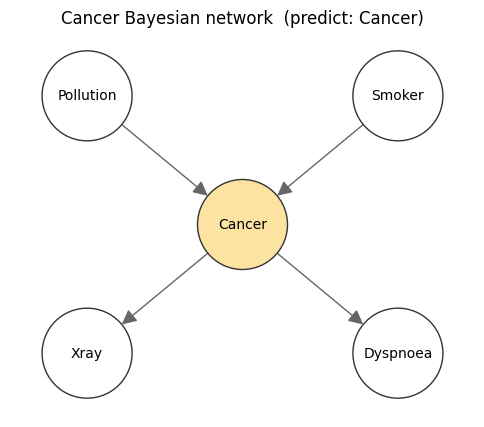

In [4]:
import networkx as nx
import matplotlib.pyplot as plt

pos = {"Pollution": (0, 2), "Smoker": (2, 2), "Cancer": (1, 1),
       "Xray": (0, 0), "Dyspnoea": (2, 0)}
G = nx.DiGraph(list(model.edges()))

fig, ax = plt.subplots(figsize=(6, 5))
node_colors = ["#FCE3A2" if n == "Cancer" else "#FFFFFF" for n in G.nodes()]
nx.draw_networkx_nodes(G, pos, node_color=node_colors, edgecolors="#333333", node_size=4200, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=10, ax=ax)
nx.draw_networkx_edges(G, pos, arrowstyle="-|>", arrowsize=22, edge_color="#666666", node_size=4200, ax=ax)
ax.margins(0.18); ax.axis("off")
ax.set_title("Cancer Bayesian network  (predict: Cancer)")
plt.show()

## Step 3: Classify = run one inference query

Classification here is just **inference**: fix the variables we observe (evidence) and
ask for the posterior probability of the target. We use exact inference (Variable
Elimination). The predicted class is simply the most probable state.

In [5]:
from pgmpy.inference import VariableElimination
infer = VariableElimination(model)

# Prior belief, before seeing anything:
print("\nPRIOR  P(Cancer):")
print(infer.query(["Cancer"], show_progress=False))

# A classification query: a smoker who has dyspnoea and a positive X-ray.
evidence = {"Smoker": "smoker", "Dyspnoea": "present", "Xray": "positive"}
print("\nPOSTERIOR  P(Cancer | evidence):")
print(infer.query(["Cancer"], evidence=evidence, show_progress=False))

def classify(evidence):
    q = infer.query(["Cancer"], evidence=evidence, show_progress=False)
    label = q.state_names["Cancer"][q.values.argmax()]
    return label, float(q.values.max())

label, prob = classify(evidence)
print(f"\nPredicted class: Cancer = {label}   (probability {prob:.1%})")

/usr/local/lib/python3.12/dist-packages/pgmpy/estimators/__init__.py:4: FutureWarning: `pgmpy.estimators.StructureScore` is deprecated and will be removed in v1.3.0. Use `pgmpy.structure_score` instead.
  from .StructureScore import (



PRIOR  P(Cancer):
+---------------+---------------+
| Cancer        |   phi(Cancer) |
+===============+===============+
| Cancer(True)  |        0.0116 |
+---------------+---------------+
| Cancer(False) |        0.9884 |
+---------------+---------------+

POSTERIOR  P(Cancer | evidence):
+---------------+---------------+
| Cancer        |   phi(Cancer) |
+===============+===============+
| Cancer(True)  |        0.2438 |
+---------------+---------------+
| Cancer(False) |        0.7562 |
+---------------+---------------+

Predicted class: Cancer = False   (probability 75.6%)


## Step 4: Watch the belief update: *on the network itself*

We annotate the **same DAG** with probabilities and step through the evidence.

- **Gold** node = something we observed (its value is fixed).
- **Blue** node = still unknown; it shows `P(state)` and darkens as that probability rises.
- The **Cancer** node (thick border) is the class we predict; watch its number climb.

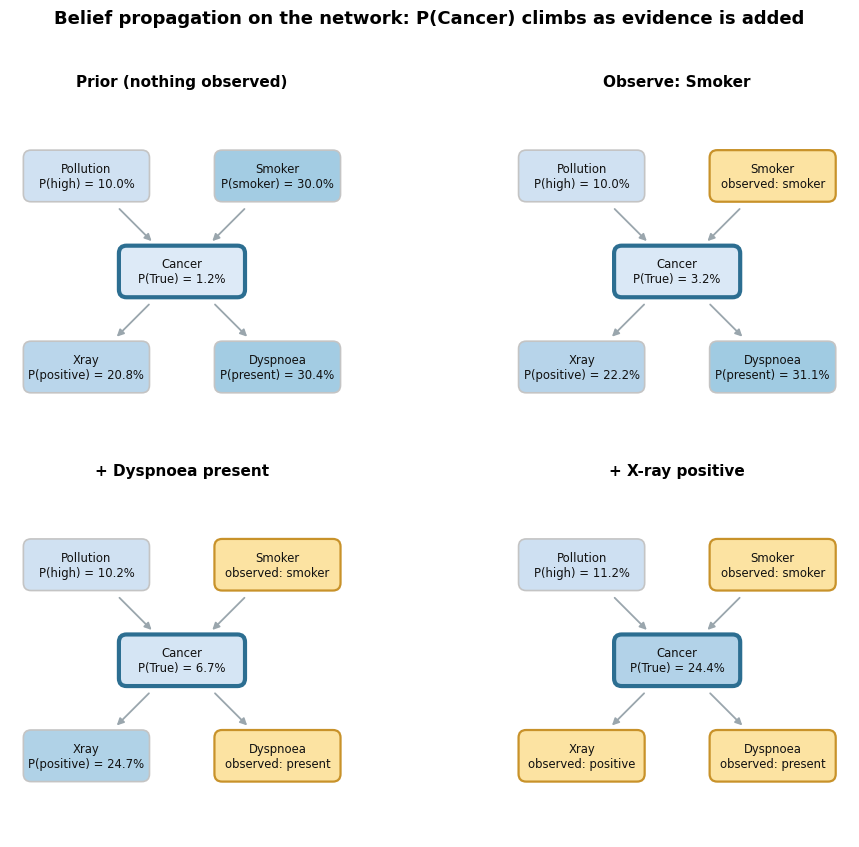

Prior (nothing observed)     P(Cancer=True) =  1.16%
Observe: Smoker              P(Cancer=True) =  3.20%
+ Dyspnoea present           P(Cancer=True) =  6.68%
+ X-ray positive             P(Cancer=True) = 24.38%


In [6]:
from matplotlib.patches import FancyBboxPatch
import numpy as np

report = {"Pollution": "high", "Smoker": "smoker", "Cancer": "True", "Xray": "positive", "Dyspnoea": "present"}
edges = list(model.edges()); BW, BH = 1.30, 0.52

def marginal(var, ev):
    q = infer.query([var], evidence=ev, show_progress=False)
    return q.get_value(**{var: report[var]})

def _trim(a, b, ra, rb):
    a, b = np.array(a, float), np.array(b, float)
    u = (b - a) / np.hypot(*(b - a)); return a + u * ra, b - u * rb

def draw_state(ax, ev, title):
    ax.set_xlim(-0.8, 2.8); ax.set_ylim(-0.85, 2.85); ax.set_aspect("equal"); ax.axis("off")
    ax.set_title(title, fontsize=11, fontweight="bold")
    for a, b in edges:
        s, e = _trim(pos[a], pos[b], 0.46, 0.42)
        ax.annotate("", xy=e, xytext=s, arrowprops=dict(arrowstyle="-|>", color="#9aa6ad", lw=1.3))
    for var, (x, y) in pos.items():
        is_cancer = (var == "Cancer")
        if var in ev:
            fc, ec, lw = "#FCE3A2", "#C8922A", (2.4 if is_cancer else 1.6)
            label, tcol = f"{var}\nobserved: {ev[var]}", "#111111"
        else:
            p = marginal(var, ev)
            fc = plt.cm.Blues(0.12 + 0.8 * min(p, 1.0))
            ec, lw = ("#2C6E91" if is_cancer else "#c4c4c4"), (3.0 if is_cancer else 1.2)
            label = f"{var}\nP({report[var]}) = {p*100:.1f}%"; tcol = "#ffffff" if p > 0.6 else "#111111"
        ax.add_patch(FancyBboxPatch((x - BW/2, y - BH/2), BW, BH,
            boxstyle="round,pad=0.01,rounding_size=0.08", facecolor=fc, edgecolor=ec, linewidth=lw))
        ax.text(x, y, label, ha="center", va="center", fontsize=8.4, color=tcol)

stages = [
    ("Prior (nothing observed)", {}),
    ("Observe: Smoker",          {"Smoker": "smoker"}),
    ("+ Dyspnoea present",       {"Smoker": "smoker", "Dyspnoea": "present"}),
    ("+ X-ray positive",         {"Smoker": "smoker", "Dyspnoea": "present", "Xray": "positive"}),
]
fig, axes = plt.subplots(2, 2, figsize=(11, 8.6))
for ax, (title, ev) in zip(axes.ravel(), stages):
    draw_state(ax, ev, title)
fig.suptitle("Belief propagation on the network: P(Cancer) climbs as evidence is added", fontsize=13, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()

for title, ev in stages:
    print(f"{title:28s} P(Cancer=True) = {marginal('Cancer', ev)*100:5.2f}%")

## Step 5: Interactive demo

Tap the buttons to set what you observe; every probability on the network updates instantly.

**How it works.** When you run this cell, pgmpy computes the posterior P(node | evidence) for
*every* combination of observations (all 81 of them) up front, in Python. The cell then shows
a small HTML/JS widget that just looks up the right entry on each click; no inference
happens in JavaScript. So sections 3, 4 and this demo all use the same engine.

The cell also writes a self-contained `cancer_bayesian_network_belief_demo.html` to the
current directory, so you can open or share the standalone file.

In [7]:
import json, itertools, os
from IPython.display import HTML, display
from pgmpy.inference import VariableElimination

# --- Configuration -----------------------------------------------------------
TARGET       = 'Cancer'
OBSERVABLES  = ['Pollution', 'Smoker', 'Xray', 'Dyspnoea']
# The 'of-interest' outcome we report P(...) for each unobserved node:
REPORT_STATE = {'Pollution': 'high',     'Smoker':   'smoker',   'Cancer':   'True',
                'Xray':      'positive', 'Dyspnoea': 'present'}
# Human-friendly display labels (the deck calls the node 'X-ray', not 'Xray'):
NODE_LABEL   = {'Pollution': 'Pollution', 'Smoker': 'Smoker', 'Xray': 'X-ray',
                'Dyspnoea':  'Dyspnoea',  'Cancer': 'Cancer'}
def _state_label(s):              # 'non_smoker' -> 'Non-smoker'
    return s.replace('_', '-').capitalize() if s.islower() else s

# --- Step 1: pre-compute every evidence pattern with pgmpy (source of truth) -
def precompute(model, observables, target, report_state):
    infer = VariableElimination(model)
    state_names = {n: list(model.get_cpds(n).state_names[n])
                   for n in [*observables, target]}
    lookup = {}
    for combo in itertools.product(*[[None, *state_names[n]] for n in observables]):
        ev  = {n: v for n, v in zip(observables, combo) if v is not None}
        key = '|'.join(ev.get(n, '?') for n in observables)
        marg = {}
        for node in [*observables, target]:
            if node in ev:
                continue
            q = infer.query([node], evidence=ev, show_progress=False)
            marg[node] = float(q.get_value(**{node: report_state[node]}))
        lookup[key] = marg
    return lookup, state_names

LOOKUP, STATE_NAMES = precompute(model, OBSERVABLES, TARGET, REPORT_STATE)
print(f'Pre-computed {len(LOOKUP)} evidence patterns '
      f'({len(json.dumps(LOOKUP))} bytes of JSON).')

# --- Step 2: assemble the HTML in pieces (no big literal blob) ---------------
def _controls_html():
    parts = []
    for node in OBSERVABLES:
        opts = '<button data-v="">Unknown</button>'
        for s in STATE_NAMES[node]:
            opts += f'<button data-v="{s}">{_state_label(s)}</button>'
        parts.append(
            '<div style="border:1px solid #dcdcdc;border-radius:8px;padding:8px 10px;">'
            f'<div style="font-size:12px;color:#6b7780;margin-bottom:6px;">{NODE_LABEL[node]}</div>'
            f'<div class="bnseg" data-node="{node}" style="display:flex;gap:4px;">{opts}</div>'
            '</div>')
    return ('<div style="display:grid;grid-template-columns:1fr 1fr;gap:10px;margin:6px 0 14px;">'
            + ''.join(parts) + '</div>')

# Network drawing: fixed layout for this 5-node Cancer example.
SVG_HTML = r'''<svg width="100%" viewBox="0 0 680 300" role="img" aria-label="Cancer Bayesian network">
<defs><marker id="bnar" viewBox="0 0 10 10" refX="8" refY="5" markerWidth="6" markerHeight="6" orient="auto-start-reverse">
<path d="M2 1L8 5L2 9" fill="none" stroke="#9aa6ad" stroke-width="1.6" stroke-linecap="round" stroke-linejoin="round"/></marker></defs>
<line x1="160" y1="74" x2="306" y2="120" stroke="#9aa6ad" stroke-width="1.3" marker-end="url(#bnar)"/>
<line x1="520" y1="74" x2="374" y2="120" stroke="#9aa6ad" stroke-width="1.3" marker-end="url(#bnar)"/>
<line x1="306" y1="178" x2="160" y2="222" stroke="#9aa6ad" stroke-width="1.3" marker-end="url(#bnar)"/>
<line x1="374" y1="178" x2="520" y2="222" stroke="#9aa6ad" stroke-width="1.3" marker-end="url(#bnar)"/>
<g><rect id="n_Pollution" x="90" y="20" width="140" height="52" rx="8" fill="#ffffff" stroke="#c4c4c4" stroke-width="1"/>
<text x="160" y="42" text-anchor="middle" font-size="14" font-weight="600" fill="#1f2a30">Pollution</text>
<text id="v_Pollution" x="160" y="60" text-anchor="middle" font-size="11.5" fill="#33424a">.</text></g>
<g><rect id="n_Smoker" x="450" y="20" width="140" height="52" rx="8" fill="#ffffff" stroke="#c4c4c4" stroke-width="1"/>
<text x="520" y="42" text-anchor="middle" font-size="14" font-weight="600" fill="#1f2a30">Smoker</text>
<text id="v_Smoker" x="520" y="60" text-anchor="middle" font-size="11.5" fill="#33424a">.</text></g>
<g><rect id="n_Cancer" x="270" y="118" width="140" height="60" rx="8" fill="#ffffff" stroke="#2C6E91" stroke-width="2.6"/>
<text x="340" y="143" text-anchor="middle" font-size="14" font-weight="700" fill="#1f2a30">Cancer</text>
<text id="v_Cancer" x="340" y="163" text-anchor="middle" font-size="13" font-weight="600" fill="#2C6E91">.</text></g>
<g><rect id="n_Xray" x="90" y="224" width="140" height="52" rx="8" fill="#ffffff" stroke="#c4c4c4" stroke-width="1"/>
<text x="160" y="246" text-anchor="middle" font-size="14" font-weight="600" fill="#1f2a30">X-ray</text>
<text id="v_Xray" x="160" y="264" text-anchor="middle" font-size="11.5" fill="#33424a">.</text></g>
<g><rect id="n_Dyspnoea" x="450" y="224" width="140" height="52" rx="8" fill="#ffffff" stroke="#c4c4c4" stroke-width="1"/>
<text x="520" y="246" text-anchor="middle" font-size="14" font-weight="600" fill="#1f2a30">Dyspnoea</text>
<text id="v_Dyspnoea" x="520" y="264" text-anchor="middle" font-size="11.5" fill="#33424a">.</text></g>
</svg>'''

READOUT_HTML = r'''<div style="display:flex;justify-content:space-between;align-items:baseline;margin-bottom:4px;">
<div style="font-size:13px;color:#6b7780;">P(Cancer = True | evidence)</div>
<div id="pct" style="font-size:22px;font-weight:600;">.</div></div>
<div style="height:30px;border-radius:6px;background:#eef1f3;border:1px solid #dde3e6;position:relative;overflow:hidden;">
<div id="fill" style="height:100%;width:0;background:#3A7CA5;transition:width .6s cubic-bezier(.4,0,.2,1);"></div>
<div id="prior" style="position:absolute;top:0;bottom:0;width:2px;background:#99a6ad;" title="prior"></div></div>
<div style="display:flex;justify-content:space-between;align-items:center;margin-top:12px;font-size:12px;color:#6b7780;">
<div id="verdict">.</div>
<button id="bnreset" style="font-size:12px;padding:6px 12px;border:1px solid #cfd6da;background:#fff;color:#1f2a30;border-radius:6px;cursor:pointer;">Clear all evidence</button></div>'''

STYLES_HTML = ('<style>'
 '#bnDemo .bnseg button{flex:1;font-family:inherit;font-size:12px;padding:6px 4px;'
 'border:1px solid #cfd6da;background:#fff;color:#55636b;border-radius:6px;cursor:pointer;}'
 '#bnDemo .bnseg button.on{background:#3A7CA5;border-color:#3A7CA5;color:#fff;}'
 '</style>')

# Thin JS: lookup + DOM updates only. No probability math here.
JS_TEMPLATE = r'''<script>
(function(){
 const CONFIG = /*CONFIG*/;
 const LOOKUP = CONFIG.LOOKUP, OBSERVABLES = CONFIG.OBSERVABLES,
       REPORT_STATE = CONFIG.REPORT_STATE, PRIOR_KEY = CONFIG.PRIOR_KEY;
 let state = {}; OBSERVABLES.forEach(function(n){ state[n] = null; });
 function keyStr(){ return OBSERVABLES.map(function(n){ return state[n] || "?"; }).join("|"); }
 function tint(p){
  var t = Math.min(0.08 + 0.6*p, 1);
  return "rgb(" + Math.round(255+(58-255)*t) + "," + Math.round(255+(124-255)*t) + "," + Math.round(255+(165-255)*t) + ")";
 }
 function $(id){ return document.getElementById(id); }
 function render(){
  var m = LOOKUP[keyStr()];
  OBSERVABLES.forEach(function(node){
   var rect = $("n_"+node), vt = $("v_"+node);
   if (state[node]){
    rect.setAttribute("fill","#FCE3A2"); rect.setAttribute("stroke","#C8922A"); rect.setAttribute("stroke-width","1.6");
    vt.textContent = "observed: " + state[node]; vt.setAttribute("fill","#7a5a12");
   } else {
    var p = m[node];
    rect.setAttribute("fill", tint(p)); rect.setAttribute("stroke","#c4c4c4"); rect.setAttribute("stroke-width","1");
    vt.textContent = "P(" + REPORT_STATE[node] + ") = " + (p*100).toFixed(1) + "%";
    vt.setAttribute("fill","#33424a");
   }
  });
  var pc = m["Cancer"];
  $("n_Cancer").setAttribute("fill", tint(pc));
  $("v_Cancer").textContent = "P(True) = " + (pc*100).toFixed(1) + "%";
  $("fill").style.width = (pc*100).toFixed(2) + "%";
  $("pct").textContent = (pc*100).toFixed(1) + "%";
  $("verdict").innerHTML = "Most likely: <b>" + (pc>=0.5?"cancer":"not cancer") + "</b>";
 }
 var root = $("bnDemo");
 root.querySelectorAll(".bnseg").forEach(function(seg){
  var node = seg.getAttribute("data-node");
  seg.querySelectorAll("button").forEach(function(b){
   b.addEventListener("click", function(){
    var v = b.getAttribute("data-v");
    state[node] = v === "" ? null : v;
    seg.querySelectorAll("button").forEach(function(x){ x.classList.remove("on"); });
    b.classList.add("on");
    render();
   });
  });
  seg.querySelector('button[data-v=""]').classList.add("on");
 });
 $("bnreset").addEventListener("click", function(){
  OBSERVABLES.forEach(function(n){ state[n] = null; });
  root.querySelectorAll(".bnseg").forEach(function(seg){
   seg.querySelectorAll("button").forEach(function(x){ x.classList.remove("on"); });
   seg.querySelector('button[data-v=""]').classList.add("on");
  });
  render();
 });
 $("prior").style.left = (LOOKUP[PRIOR_KEY]["Cancer"]*100) + "%";
 render();
})();
</script>'''

INTRO_HTML = ('<div style="font-size:13px;color:#6b7780;margin-bottom:8px;">'
              'Tap a control to set <b>what you observe</b>. Every probability on the '
              'network updates instantly. All values come from a lookup table that '
              '<b>pgmpy</b> pre-computed in Python above.</div>')

config = {'LOOKUP': LOOKUP, 'OBSERVABLES': OBSERVABLES,
          'REPORT_STATE': REPORT_STATE,
          'PRIOR_KEY': '|'.join('?' for _ in OBSERVABLES)}

body = ('<div id="bnDemo" style="font-family:-apple-system,Segoe UI,Roboto,Helvetica,Arial,sans-serif;'
        'color:#1f2a30;background:#ffffff;border:1px solid #e3e3e3;border-radius:12px;padding:16px;'
        'max-width:720px;margin:8px auto;">'
        + INTRO_HTML + SVG_HTML + _controls_html() + READOUT_HTML + STYLES_HTML
        + JS_TEMPLATE.replace('/*CONFIG*/', json.dumps(config)) + '</div>')

# --- Step 3: write standalone HTML to the current directory ------------------
out_path = 'cancer_bayesian_network_belief_demo.html'
with open(out_path, 'w') as f:
    f.write('<!DOCTYPE html><html lang="en"><head><meta charset="utf-8">'
            '<meta name="viewport" content="width=device-width,initial-scale=1">'
            '<title>Cancer Bayesian Network interactive demo</title></head>'
            '<body style="margin:0;padding:24px;background:#f4f6f7;">' + body + '</body></html>')
print(f'Saved standalone demo to: {os.path.abspath(out_path)}')

# --- Step 4: also show it inline ---------------------------------------------
display(HTML(body))

Pre-computed 81 evidence patterns (7877 bytes of JSON).
Saved standalone demo to: /content/cancer_bayesian_network_belief_demo.html
